In [1]:
import pandas as pd
import numpy as np

# Synthetic Imbalanced Credit Card Fraud Dataset Generator
np.random.seed(42)
n_samples = 5000
fraud_ratio = 0.02  # ~2% Fraud cases (Heavily imbalanced)

n_fraud = int(n_samples * fraud_ratio)
n_legit = n_samples - n_fraud

# Simulate features V1-V5 (PCA components), Time, Amount, Class
time_legit = np.random.uniform(0, 172800, n_legit) # Seconds over 2 days
time_fraud = np.random.uniform(0, 172800, n_fraud)

amount_legit = np.random.exponential(scale=88, size=n_legit)
amount_fraud = np.random.normal(loc=120, scale=50, size=n_fraud).clip(min=1)

v1_legit = np.random.normal(0, 1, n_legit)
v1_fraud = np.random.normal(-3, 1.5, n_fraud) # Shifted distribution for fraud

v2_legit = np.random.normal(0, 1, n_legit)
v2_fraud = np.random.normal(2.5, 1.2, n_fraud)

df_legit = pd.DataFrame({'Time': time_legit, 'V1': v1_legit, 'V2': v2_legit, 'Amount': amount_legit, 'Class': 0})
df_fraud = pd.DataFrame({'Time': time_fraud, 'V1': v1_fraud, 'V2': v2_fraud, 'Amount': amount_fraud, 'Class': 1})

df_credit = pd.concat([df_legit, df_fraud]).sample(frac=1, random_state=42).reset_index(drop=True)
df_credit.to_csv('creditcard.csv', index=False)
print("Dataset 'creditcard.csv' successfully generated.")

Dataset 'creditcard.csv' successfully generated.


Total Transactions : 5000
Legitimate (Class 0): 4900
Fraudulent (Class 1): 100
Fraud Percentage    : 2.00%


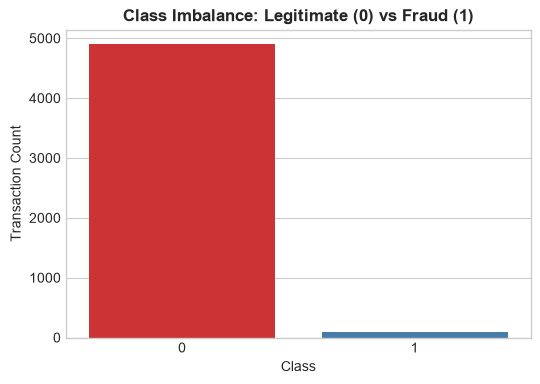

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Load dataset
df = pd.read_csv('creditcard.csv')

# Class Ratio
counts = df['Class'].value_counts()
fraud_pct = (counts[1] / len(df)) * 100

print(f"Total Transactions : {len(df)}")
print(f"Legitimate (Class 0): {counts[0]}")
print(f"Fraudulent (Class 1): {counts[1]}")
print(f"Fraud Percentage    : {fraud_pct:.2f}%")

# Bar Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class', hue='Class', palette='Set1', legend=False)
plt.title('Class Imbalance: Legitimate (0) vs Fraud (1)', fontsize=12, fontweight='bold')
plt.ylabel('Transaction Count')
plt.show()

C:\Users\hk516\AppData\Local\Temp\ipykernel_8756\2134891975.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0], palette='Set2')


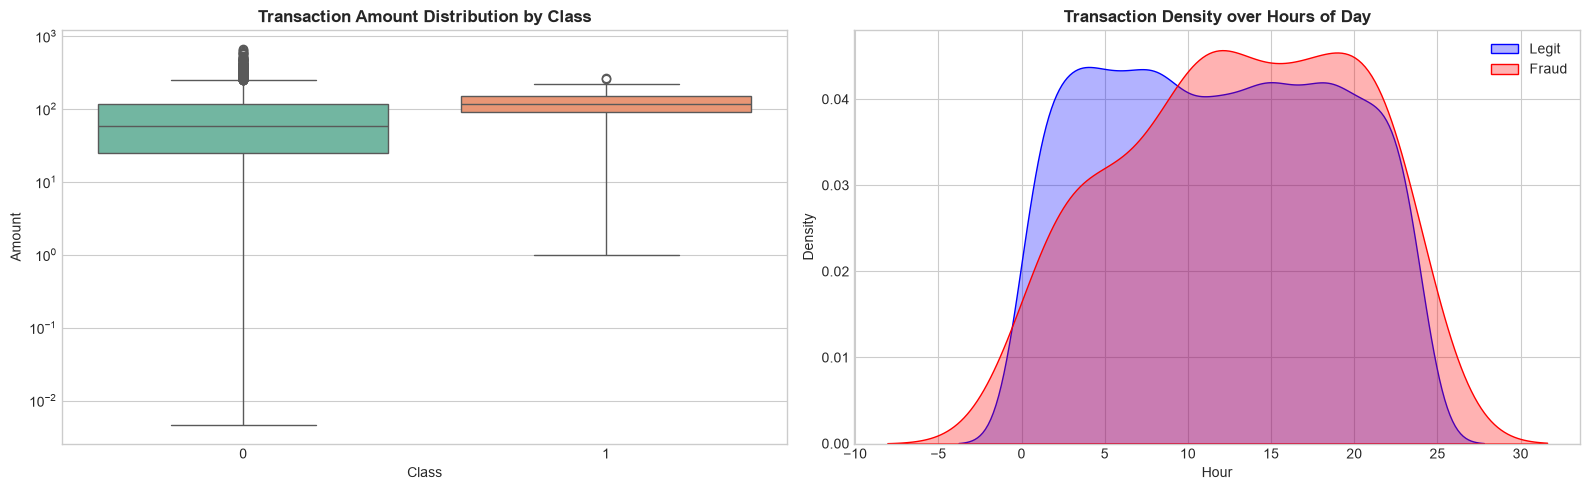

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Transaction Amount Distribution
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0], palette='Set2')
axes[0].set_title('Transaction Amount Distribution by Class', fontsize=12, fontweight='bold')
axes[0].set_yscale('log') # Log scale for visualization

# Time of Day Analysis (Converted to Hours)
df['Hour'] = (df['Time'] / 3600) % 24
sns.kdeplot(data=df[df['Class'] == 0]['Hour'], ax=axes[1], label='Legit', color='blue', fill=True, alpha=0.3)
sns.kdeplot(data=df[df['Class'] == 1]['Hour'], ax=axes[1], label='Fraud', color='red', fill=True, alpha=0.3)
axes[1].set_title('Transaction Density over Hours of Day', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Features & Target
X = df.drop(['Class', 'Hour'], axis=1)
y = df['Class']

# Stratified Train/Test Split (Preserves Fraud ratio in both splits)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Apply SMOTE strictly on Training set (Prevents Data Leakage)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original Training Class Ratio : {y_train.value_counts().to_dict()}")
print(f"Resampled Training Class Ratio: {pd.Series(y_train_resampled).value_counts().to_dict()}")

Original Training Class Ratio : {0: 3920, 1: 80}
Resampled Training Class Ratio: {0: 3920, 1: 3920}


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Initialize Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Dictionary to store predictions
predictions = {}

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    predictions[name] = {'pred': y_pred, 'proba': y_proba, 'model': model}
    print(f"Model trained: {name}")

Model trained: Logistic Regression
Model trained: Random Forest


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99       980
       Fraud       0.43      0.80      0.56        20

    accuracy                           0.97      1000
   macro avg       0.71      0.89      0.77      1000
weighted avg       0.98      0.97      0.98      1000

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99       980
       Fraud       0.71      0.75      0.73        20

    accuracy                           0.99      1000
   macro avg       0.85      0.87      0.86      1000
weighted avg       0.99      0.99      0.99      1000



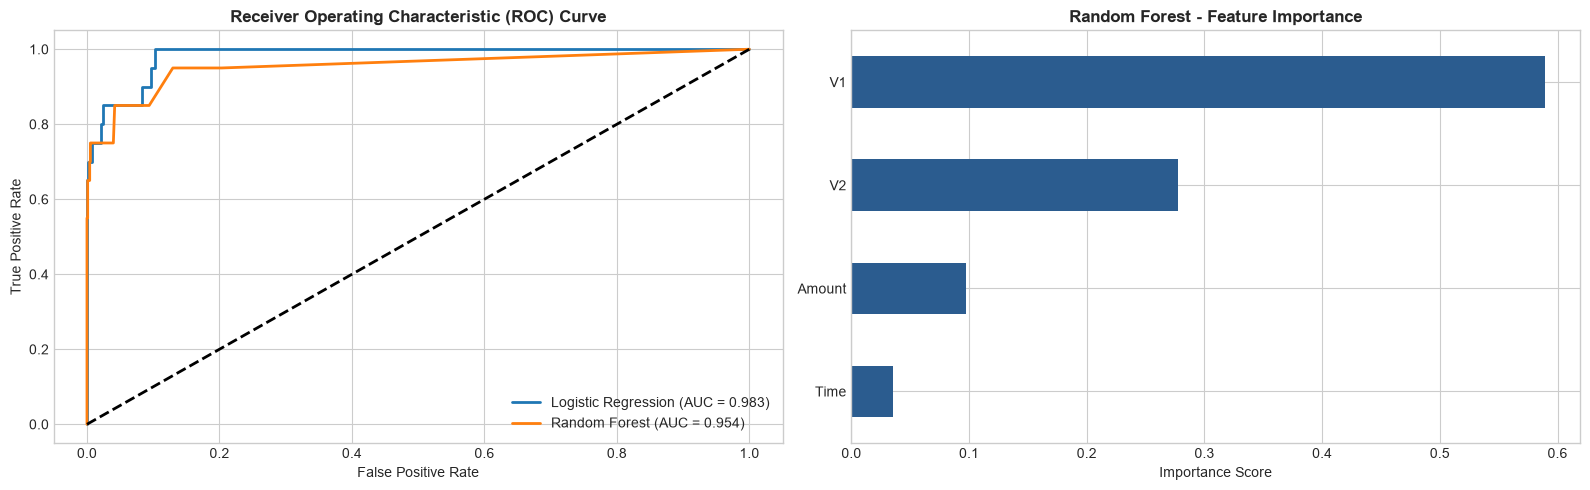

In [7]:
from sklearn.metrics import classification_report, roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ROC Curve Plot
for name, meta in predictions.items():
    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test, meta['pred'], target_names=['Legit', 'Fraud']))
    
    fpr, tpr, _ = roc_curve(y_test, meta['proba'])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Precision vs Recall Trade-off Discussion Matrix
rf_model = predictions['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

importances.plot(kind='barh', ax=axes[1], color='#2b5c8f')
axes[1].set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## Fraud Metric Priority & High-Scale System Scalability

### 1. Recall vs. Precision Trade-off
* **Recall is the Primary Metric:** In fraud detection, **Recall** ($\frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$) is far more critical than Precision. A **False Negative** means a fraudulent transaction passes through undetected, causing direct financial loss. Conversely, a **False Positive** merely prompts an automated SMS verification or temporary block.

### 2. High-Throughput Scalability (1 Million Transactions / Hour)
To process ~280 transactions per second at peak scale:
* **Feature Store Integration:** Store real-time streaming aggregates (e.g., 5-minute transaction frequency) in in-memory key-value stores like Redis or Feast.
* **Model Choice for Latency:** While Random Forest offers strong AUC-ROC, lightweight models like **XGBoost (C++ backend)** or quantized ONNX Logistic Regression pipelines run sub-millisecond inferences.
* **Asynchronous Pipelines:** Deploy model scoring via distributed microservices (Docker/Kubernetes + Kafka streaming) to decoupling prediction steps from database I/O.